### 1.Load data

In [ ]:
import scanpy as sc # cross celltype predict
import scresid
# import pertpy as pt # download dataset
import warnings
warnings.filterwarnings('ignore')
adata = sc.read_h5ad('./data/dialogue.h5ad')
adata

AnnData object with n_obs × n_vars = 5374 × 6329
    obs: 'nCount_RNA', 'nFeature_RNA', 'cellQ', 'gender', 'location', 'clinical.status', 'cell.subtypes', 'pathology', 'origin', 'subset', 'sample', 'path_str'
    var: 'name'

In [2]:
adata.obs.rename(columns={"clinical.status": 'condition'}, inplace=True) # dialogue
adata.obs.rename(columns={'cell.subtypes': 'cell_type'}, inplace=True)
adata.obs["condition"].replace({"Healthy": "control"}, inplace=True)
adata.obs["condition"].replace({"Non-inflamed": "stimulated"}, inplace=True)
adata.obs["condition"].replace({"Inflamed": "stimulated"}, inplace=True)

In [3]:
adata = sc.AnnData(adata.X, obs=adata.obs.copy(), var=adata.var.copy())
adata.obs_names_make_unique()
print(adata)
print('\n', adata.obs['condition'].value_counts())
print('\n', adata.obs['cell_type'].value_counts())

AnnData object with n_obs × n_vars = 5374 × 6329
    obs: 'nCount_RNA', 'nFeature_RNA', 'cellQ', 'gender', 'location', 'condition', 'cell_type', 'pathology', 'origin', 'subset', 'sample', 'path_str'
    var: 'name'

 condition
stimulated    3246
control       2128
Name: count, dtype: int64

 cell_type
TA2            1905
Macrophages    1452
CD8+ LP        1166
CD8+ IELs       752
CD8+ IL17+       99
Name: count, dtype: int64


### 2.Build and train models

In [4]:
model = scresid.SCRESID(input_dim=adata.n_vars, device='cuda:0')
model = model.to(model.device)
# key_dic varies with the adata
key_dic = {'condition_key': 'condition',
           'cell_type_key': 'cell_type',
           'ctrl_key': 'control',
           'stim_key': 'stimulated',
           'pred_key': 'predict',
           }


In [ ]:
cell_to_pred = 'TA2' # Macrophages, Macrophages, CD8+ IELs, CD8+ IL17+
# The training set does not contain the type of data to be predicted after the perturbation
train = adata[~((adata.obs[key_dic['cell_type_key']] == cell_to_pred) &
               (adata.obs[key_dic['condition_key']] == key_dic['stim_key']))]
model.train_SCRESID(train, lr=5e-5, epochs=100)

Training Epoch 99: 100%|██████████| 100/100 [00:56<00:00,  1.77it/s]


### 3.Predict

In [6]:
adata_to_pred = adata[((adata.obs[key_dic['cell_type_key']] == cell_to_pred) &
                       (adata.obs[key_dic['condition_key']] == key_dic['ctrl_key']))]
pred = model.predict(train_adata=train,
                     cell_to_pred=cell_to_pred,
                     key_dic=key_dic,
                     ratio=0.005 # The ratio need to vary with the size of dataset
                     )  
print(pred)

Get adata of TA2 and control...
Get adata of without TA2 and control...
Get stimulated adata of condition...
Get latent adata of control and stimulated...
Compute distance of stimulated and control by POT...
Compute G of stimulated and control by emd in POT...
Match max idx from G...
Get delta list of matched stimulated and control...
Get latent adata of TA2...
Compute cosine similarity with latent adata of TA2 and control...
Select top control with ratio 0.005...
Normalize weights of 8 top cosine similarity...
Compute delta of predict...
Decode predict latent embedding...
Create predict adata and save key predict...
Predict process completed.
AnnData object with n_obs × n_vars = 723 × 6329
    obs: 'nCount_RNA', 'nFeature_RNA', 'cellQ', 'gender', 'location', 'condition', 'cell_type', 'pathology', 'origin', 'subset', 'sample', 'path_str'
    var: 'name'


### 4.Evaluation

PCA cluster results...


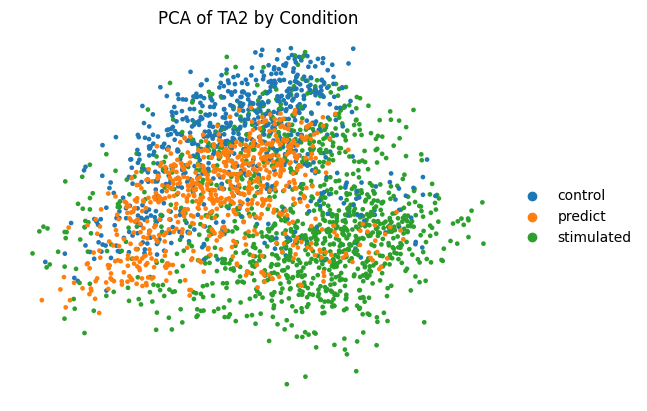

Compute rank_genes_groups...
Select common DEGS...
Common DEGs:  0
Regression plot of mean...


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


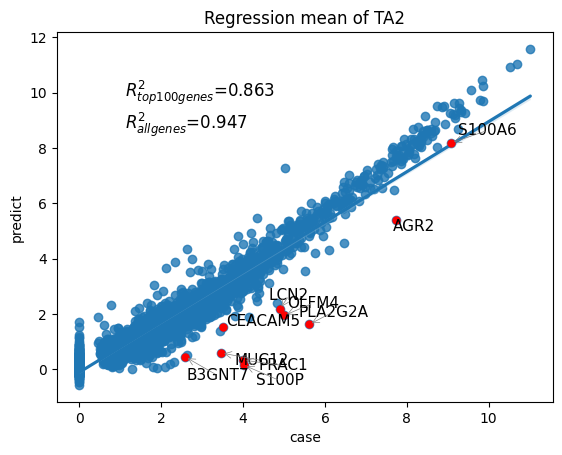

R2 mean of all genes 0.947, top genes 0.863
Regression plot of var...


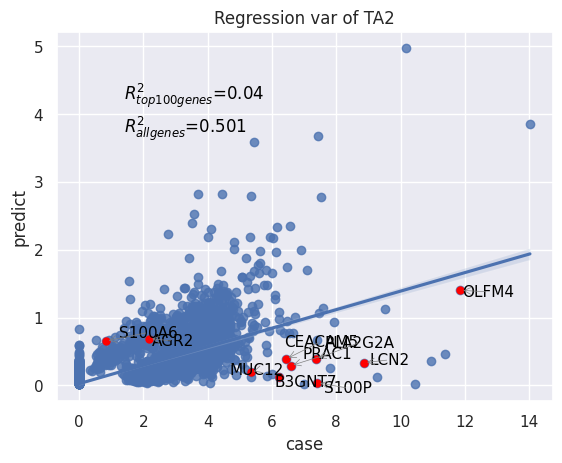

R2 var of all genes 0.501, top genes 0.04
Plot violin graph of first gene S100P...


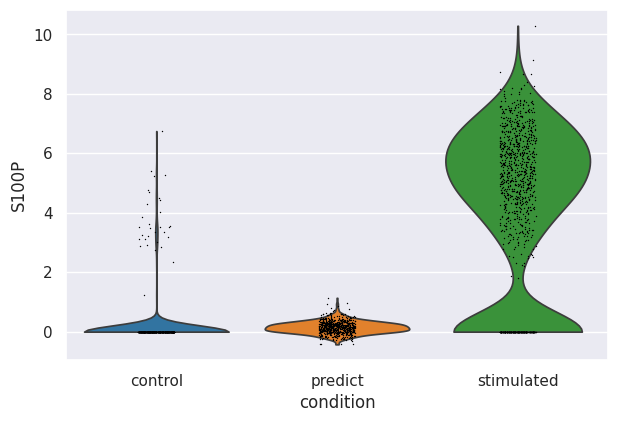

Plot violin graph of second gene PLA2G2A...


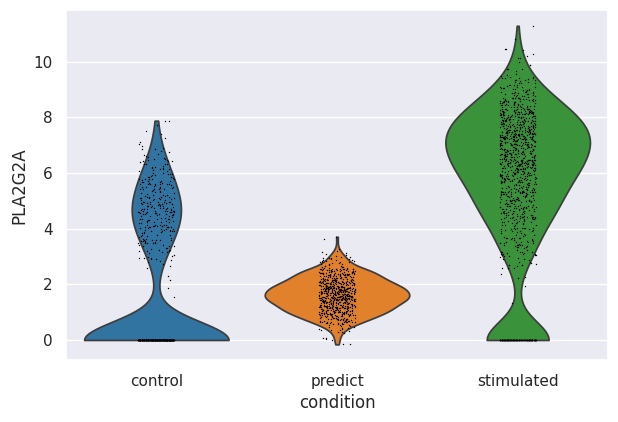

Plot violin graph of third gene PRAC1...


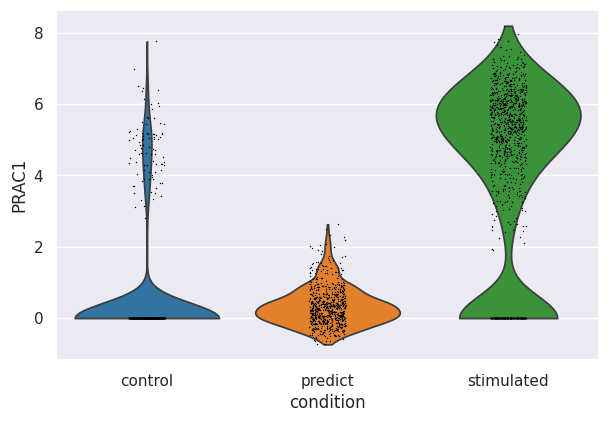

Compute DEGS contrast...
Plot 25 genes of eval_adata...


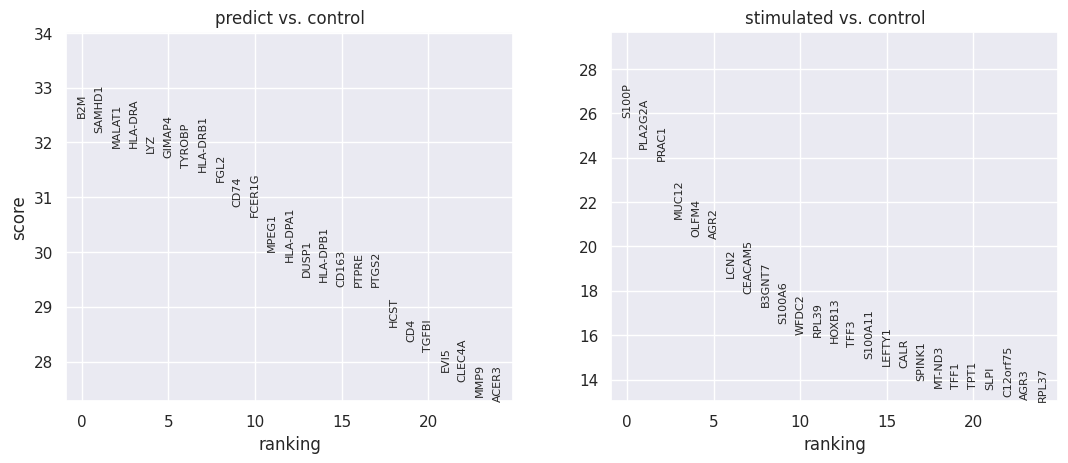

Dotplot of the first 20 genes...


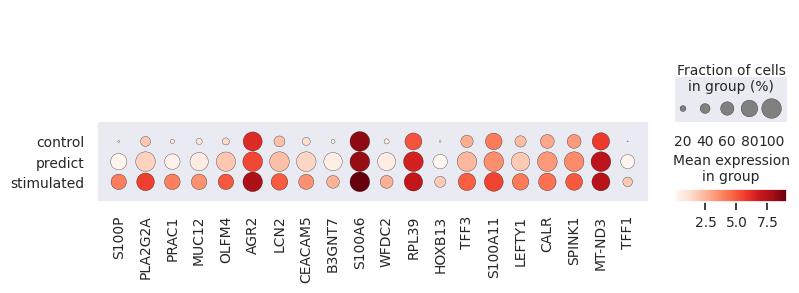

In [7]:
ground_truth = adata[(adata.obs[key_dic['cell_type_key']] == cell_to_pred)]
eval_adata = ground_truth.concatenate(pred)
scresid.evaluate(eval_adata=eval_adata, 
                        cell_type=cell_to_pred, 
                        key_dic=key_dic
                        )
